# ProXtal-LM Training Monitor

This notebook allows you to monitor training progress in real-time.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)

# Set checkpoint directory
CHECKPOINT_DIR = '../checkpoints/v11_esmc_0'
LOG_FILE = f'{CHECKPOINT_DIR}/training_metrics.csv'

## Load Training Metrics

In [10]:
# Load the CSV log
df = pd.read_csv(LOG_FILE)

print(f"Training epochs: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLatest metrics:")
display(df.tail())

Training epochs: 43

Columns: ['epoch', 'lr', 'train_loss', 'train_precision_L', 'train_precision_L2', 'train_precision_L5', 'train_recall_L', 'train_f1_L', 'train_auprc', 'train_crystal_only_precision_L', 'train_crystal_only_precision_L2', 'train_crystal_only_precision_L5', 'train_crystal_only_recall_L', 'train_crystal_only_f1_L', 'train_crystal_only_accuracy', 'train_pct_changed_positions', 'train_num_changed_positions', 'val_precision_L', 'val_precision_L2', 'val_precision_L5', 'val_recall_L', 'val_f1_L', 'val_auprc', 'val_crystal_only_precision_L', 'val_crystal_only_precision_L2', 'val_crystal_only_precision_L5', 'val_crystal_only_recall_L', 'val_crystal_only_f1_L', 'val_crystal_only_accuracy', 'val_pct_changed_positions', 'val_num_changed_positions', 'val_hyp0_tgt0_loss', 'val_hyp0_best_loss', 'val_hyp1_tgt0_loss', 'val_hyp1_best_loss', 'val_hyp2_tgt0_loss', 'val_hyp2_best_loss', 'val_loss', 'val_hyp0_tgt1_loss', 'val_hyp1_tgt1_loss', 'val_hyp2_tgt1_loss', 'val_hyp0_tgt2_loss', 'v

,epoch,lr,train_loss,train_precision_L,train_precision_L2,train_precision_L5,train_recall_L,train_f1_L,train_auprc,train_crystal_only_precision_L,...,val_hyp2_tgt0_loss,val_hyp2_best_loss,val_loss,val_hyp0_tgt1_loss,val_hyp1_tgt1_loss,val_hyp2_tgt1_loss,val_hyp0_tgt2_loss,val_hyp1_tgt2_loss,val_hyp2_tgt2_loss,best_val_loss
38,39,0.000039,4.116864,0.546060,0.603651,0.663183,0.061542,0.109046,0.272769,0.188651,...,3.029220,3.018815,3.012507,0.440958,0.447038,0.431446,0.074364,0.075365,0.073065,3.030389
39,40,0.000039,4.102450,0.561052,0.622016,0.684734,0.063254,0.112076,0.280561,0.189404,...,3.020850,3.010374,3.015665,0.441102,0.447409,0.430375,0.074338,0.075379,0.072911,3.012507
40,41,0.000039,4.090705,0.572249,0.634684,0.699625,0.064483,0.114266,0.286959,0.191128,...,3.014212,3.003574,3.010603,0.440279,0.447089,0.429545,0.074264,0.075397,0.072881,3.012507
41,42,0.000039,4.079722,0.581459,0.646059,0.712541,0.065578,0.116191,0.292289,0.191021,...,3.009304,2.998677,2.992853,0.437988,0.444159,0.428843,0.073863,0.074907,0.072747,3.010603
42,43,0.000039,4.069758,0.592235,0.658513,0.725967,0.066767,0.118307,0.298459,0.192016,...,3.004366,2.993601,3.000639,0.438708,0.445590,0.428453,0.073962,0.075101,0.072745,2.992853


## MULTIPLE LOG FILES?

In [11]:
n = 2
for i in range(4, n+1, 1):
    print(i)
    try:
        CHECKPOINT_DIR = f'../checkpoints/v3_optimal_{n}'
        LOG_FILE = f'{CHECKPOINT_DIR}/training_metrics.csv'
        df_ = pd.read_csv(LOG_FILE)
        df = pd.concat([df, df_], ignore_index=True)
    except:
        break

In [12]:
print(f"Training epochs: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLatest metrics:")
display(df.tail())

Training epochs: 43

Columns: ['epoch', 'lr', 'train_loss', 'train_precision_L', 'train_precision_L2', 'train_precision_L5', 'train_recall_L', 'train_f1_L', 'train_auprc', 'train_crystal_only_precision_L', 'train_crystal_only_precision_L2', 'train_crystal_only_precision_L5', 'train_crystal_only_recall_L', 'train_crystal_only_f1_L', 'train_crystal_only_accuracy', 'train_pct_changed_positions', 'train_num_changed_positions', 'val_precision_L', 'val_precision_L2', 'val_precision_L5', 'val_recall_L', 'val_f1_L', 'val_auprc', 'val_crystal_only_precision_L', 'val_crystal_only_precision_L2', 'val_crystal_only_precision_L5', 'val_crystal_only_recall_L', 'val_crystal_only_f1_L', 'val_crystal_only_accuracy', 'val_pct_changed_positions', 'val_num_changed_positions', 'val_hyp0_tgt0_loss', 'val_hyp0_best_loss', 'val_hyp1_tgt0_loss', 'val_hyp1_best_loss', 'val_hyp2_tgt0_loss', 'val_hyp2_best_loss', 'val_loss', 'val_hyp0_tgt1_loss', 'val_hyp1_tgt1_loss', 'val_hyp2_tgt1_loss', 'val_hyp0_tgt2_loss', 'v

,epoch,lr,train_loss,train_precision_L,train_precision_L2,train_precision_L5,train_recall_L,train_f1_L,train_auprc,train_crystal_only_precision_L,...,val_hyp2_tgt0_loss,val_hyp2_best_loss,val_loss,val_hyp0_tgt1_loss,val_hyp1_tgt1_loss,val_hyp2_tgt1_loss,val_hyp0_tgt2_loss,val_hyp1_tgt2_loss,val_hyp2_tgt2_loss,best_val_loss
38,39,0.000039,4.116864,0.546060,0.603651,0.663183,0.061542,0.109046,0.272769,0.188651,...,3.029220,3.018815,3.012507,0.440958,0.447038,0.431446,0.074364,0.075365,0.073065,3.030389
39,40,0.000039,4.102450,0.561052,0.622016,0.684734,0.063254,0.112076,0.280561,0.189404,...,3.020850,3.010374,3.015665,0.441102,0.447409,0.430375,0.074338,0.075379,0.072911,3.012507
40,41,0.000039,4.090705,0.572249,0.634684,0.699625,0.064483,0.114266,0.286959,0.191128,...,3.014212,3.003574,3.010603,0.440279,0.447089,0.429545,0.074264,0.075397,0.072881,3.012507
41,42,0.000039,4.079722,0.581459,0.646059,0.712541,0.065578,0.116191,0.292289,0.191021,...,3.009304,2.998677,2.992853,0.437988,0.444159,0.428843,0.073863,0.074907,0.072747,3.010603
42,43,0.000039,4.069758,0.592235,0.658513,0.725967,0.066767,0.118307,0.298459,0.192016,...,3.004366,2.993601,3.000639,0.438708,0.445590,0.428453,0.073962,0.075101,0.072745,2.992853


## Loss Curves

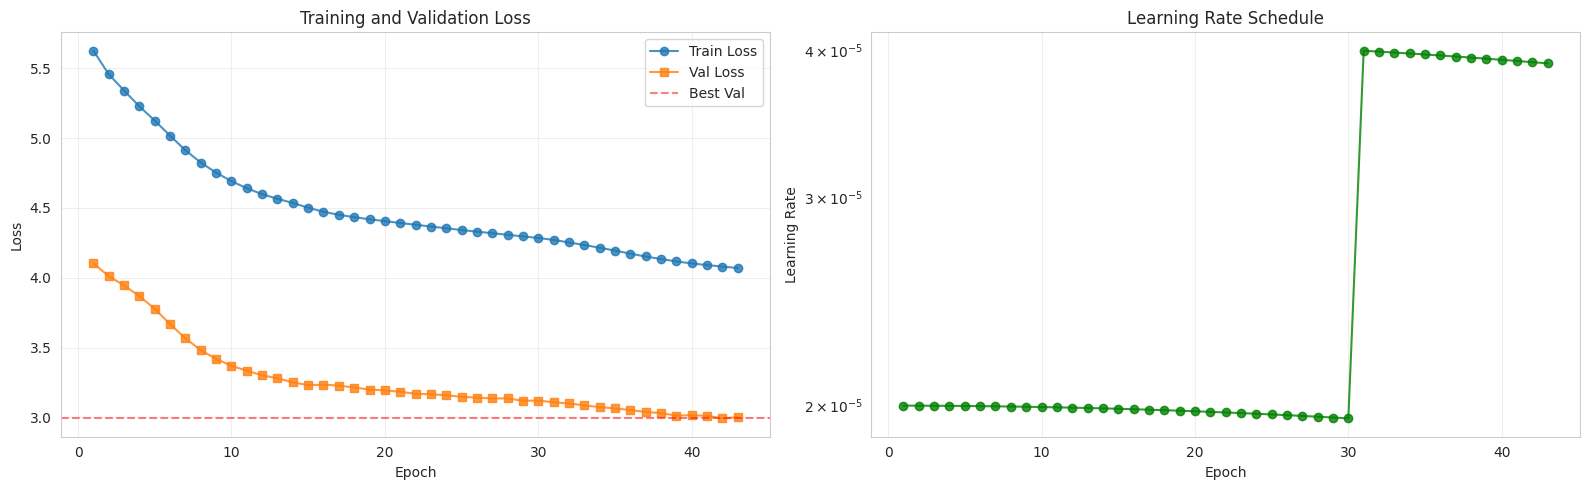

Best validation loss: 2.9929 at epoch 42


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Loss plot
ax = axes[0]
ax.plot(df['epoch'], df['train_loss'], 'o-', label='Train Loss', alpha=0.8)
ax.plot(df['epoch'], df['val_loss'], 's-', label='Val Loss', alpha=0.8)
ax.axhline(df['best_val_loss'].min(), color='r', linestyle='--', alpha=0.5, label='Best Val')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training and Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate plot
ax = axes[1]
ax.plot(df['epoch'], df['lr'], 'o-', color='green', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best validation loss: {df['val_loss'].min():.4f} at epoch {df.loc[df['val_loss'].idxmin(), 'epoch']:.0f}")

## Precision Metrics

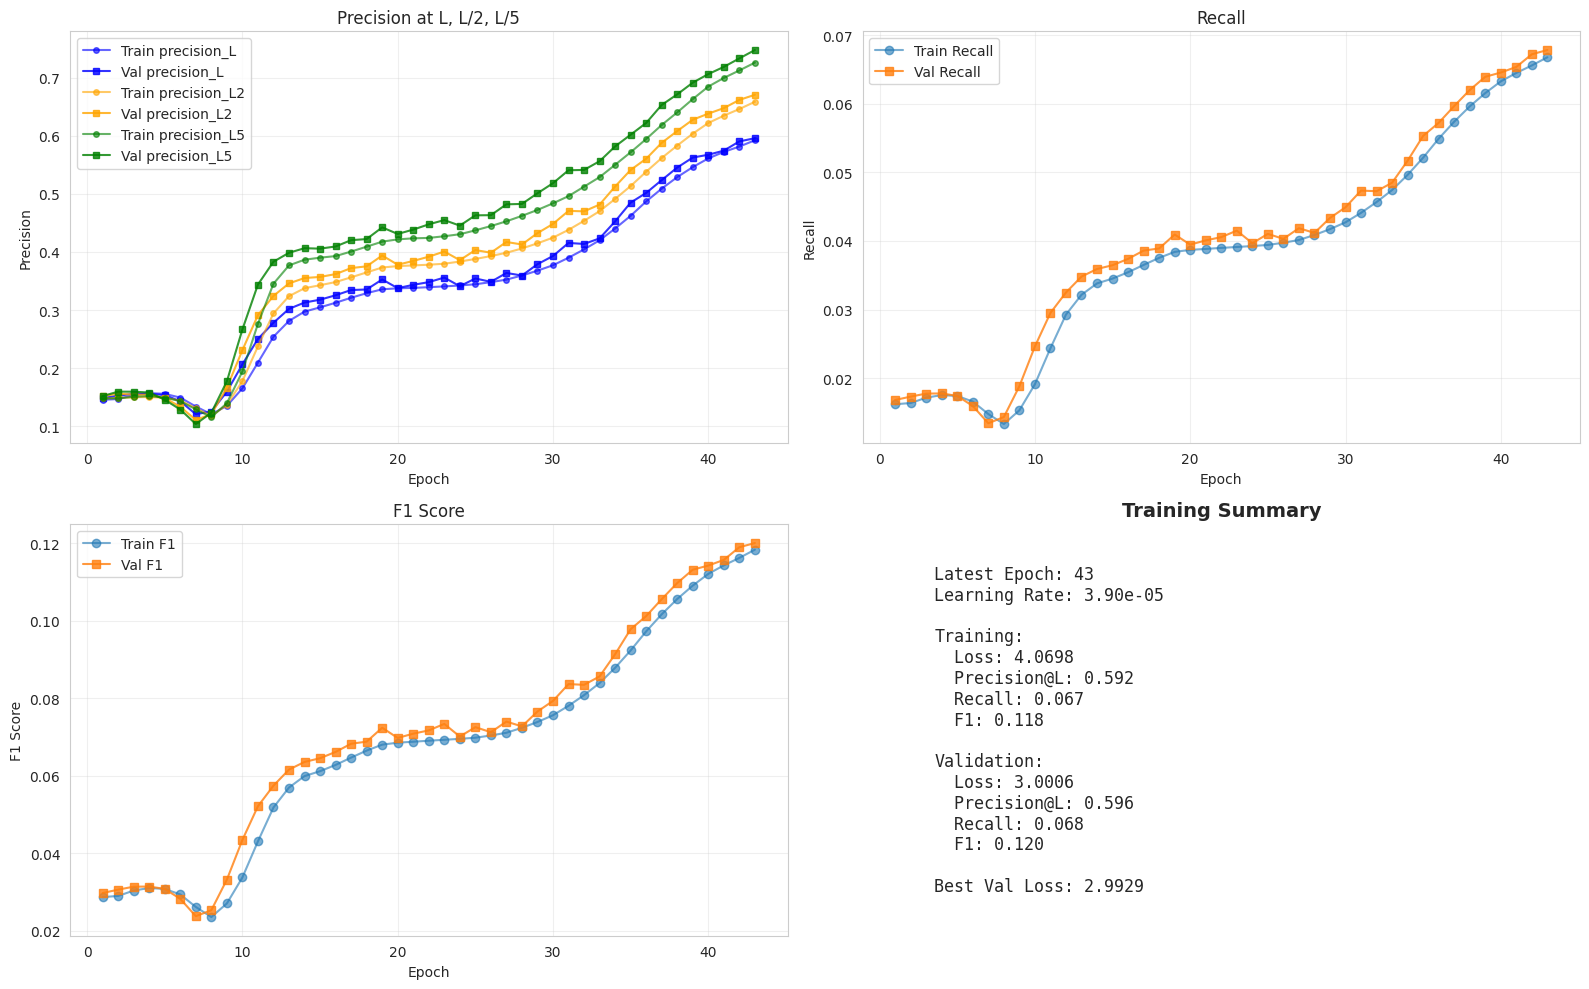

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Precision metrics
metrics = ['precision_L', 'precision_L2', 'precision_L5']
colors = ['blue', 'orange', 'green']

ax = axes[0, 0]
for metric, color in zip(metrics, colors):
    if f'train_{metric}' in df.columns:
        ax.plot(df['epoch'], df[f'train_{metric}'], 'o-', label=f'Train {metric}', 
               color=color, alpha=0.6, markersize=4)
    if f'val_{metric}' in df.columns:
        ax.plot(df['epoch'], df[f'val_{metric}'], 's-', label=f'Val {metric}', 
               color=color, alpha=0.8, markersize=5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision')
ax.set_title('Precision at L, L/2, L/5')
ax.legend()
ax.grid(True, alpha=0.3)

# Recall
ax = axes[0, 1]
if 'train_recall_L' in df.columns:
    ax.plot(df['epoch'], df['train_recall_L'], 'o-', label='Train Recall', alpha=0.6)
if 'val_recall_L' in df.columns:
    ax.plot(df['epoch'], df['val_recall_L'], 's-', label='Val Recall', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Recall')
ax.set_title('Recall')
ax.legend()
ax.grid(True, alpha=0.3)

# F1 Score
ax = axes[1, 0]
if 'train_f1_L' in df.columns:
    ax.plot(df['epoch'], df['train_f1_L'], 'o-', label='Train F1', alpha=0.6)
if 'val_f1_L' in df.columns:
    ax.plot(df['epoch'], df['val_f1_L'], 's-', label='Val F1', alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

# Summary table
ax = axes[1, 1]
ax.axis('off')
latest = df.iloc[-1]
summary_text = f"""
Latest Epoch: {latest['epoch']:.0f}
Learning Rate: {latest['lr']:.2e}

Training:
  Loss: {latest['train_loss']:.4f}
  Precision@L: {latest.get('train_precision_L', 0):.3f}
  Recall: {latest.get('train_recall_L', 0):.3f}
  F1: {latest.get('train_f1_L', 0):.3f}

Validation:
  Loss: {latest['val_loss']:.4f}
  Precision@L: {latest.get('val_precision_L', 0):.3f}
  Recall: {latest.get('val_recall_L', 0):.3f}
  F1: {latest.get('val_f1_L', 0):.3f}

Best Val Loss: {df['val_loss'].min():.4f}
"""
ax.text(0.1, 0.5, summary_text, fontsize=12, family='monospace',
        verticalalignment='center')
ax.set_title('Training Summary', fontsize=14, weight='bold')

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## Training Progress Details

In [15]:
# Calculate improvement statistics
best_epoch = df.loc[df['val_loss'].idxmin()]
current_epoch = df.iloc[-1]

print("="*60)
print("TRAINING PROGRESS SUMMARY")
print("="*60)
print(f"\nTotal epochs completed: {len(df)}")
print(f"Current learning rate: {current_epoch['lr']:.2e}")

print(f"\n{'Metric':<20} {'Best Epoch':<15} {'Current Epoch':<15}")
print("-"*60)
print(f"{'Epoch':<20} {best_epoch['epoch']:<15.0f} {current_epoch['epoch']:<15.0f}")
print(f"{'Val Loss':<20} {best_epoch['val_loss']:<15.4f} {current_epoch['val_loss']:<15.4f}")

if 'val_precision_L' in df.columns:
    print(f"{'Val Precision@L':<20} {best_epoch['val_precision_L']:<15.3f} {current_epoch['val_precision_L']:<15.3f}")
if 'val_f1' in df.columns:
    print(f"{'Val F1':<20} {best_epoch['val_f1']:<15.3f} {current_epoch['val_f1']:<15.3f}")

# Training stability
recent_val_loss = df['val_loss'].tail(5)
val_loss_std = recent_val_loss.std()
print(f"\nRecent validation loss std: {val_loss_std:.4f}")

if val_loss_std < 0.01:
    print("⚠️  Validation loss has plateaued - consider early stopping or LR reduction")
elif current_epoch['val_loss'] > best_epoch['val_loss'] * 1.05:
    print("⚠️  Validation loss increased significantly - possible overtraining")
elif current_epoch['val_loss'] == df['val_loss'].min():
    print("✅ New best model! Training is improving.")
else:
    print("📊 Training is stable and progressing.")

TRAINING PROGRESS SUMMARY

Total epochs completed: 43
Current learning rate: 3.90e-05

Metric               Best Epoch      Current Epoch  
------------------------------------------------------------
Epoch                42              43             
Val Loss             2.9929          3.0006         
Val Precision@L      0.590           0.596          

Recent validation loss std: 0.0095
⚠️  Validation loss has plateaued - consider early stopping or LR reduction


## Checkpoint Information

In [16]:
import torch
from pathlib import Path

checkpoint_dir = Path(CHECKPOINT_DIR)
checkpoints = list(checkpoint_dir.glob('*.pt'))

if checkpoints:
    print("Available checkpoints:")
    print(f"{'File':<30} {'Size (MB)':<15} {'Modified':<25}")
    print("-"*70)
    
    for ckpt in sorted(checkpoints):
        size_mb = ckpt.stat().st_size / (1024*1024)
        mtime = pd.Timestamp(ckpt.stat().st_mtime, unit='s')
        print(f"{ckpt.name:<30} {size_mb:<15.2f} {str(mtime):<25}")
    
    # Load best checkpoint info
    best_ckpt = checkpoint_dir / 'best_checkpoint.pt'
    if best_ckpt.exists():
        print("\n" + "="*70)
        print("Best Checkpoint Details")
        print("="*70)
        ckpt_data = torch.load(best_ckpt, map_location='cpu', weights_only=False)
        print(f"Epoch: {ckpt_data.get('epoch', 'N/A')}")
        print(f"Best validation loss: {ckpt_data.get('best_val_loss', 'N/A'):.4f}")
        if 'config' in ckpt_data:
            config = ckpt_data['config']
            print(f"\nModel configuration:")
            print(f"  d_model: {config.model.d_model}")
            print(f"  d_pair: {config.model.d_pair}")
            print(f"  n_blocks: {config.model.n_blocks}")
            print(f"  Learning rate: {config.training.learning_rate}")
else:
    print("No checkpoints found yet.")

Available checkpoints:
File                           Size (MB)       Modified                 
----------------------------------------------------------------------
best_checkpoint.pt             10.03           2026-04-13 15:42:59      
latest_checkpoint.pt           10.04           2026-04-13 18:21:45      

Best Checkpoint Details


ModuleNotFoundError: No module named 'proxtal_lm'

## Auto-Refresh (Optional)

Uncomment and run the cell below to auto-refresh plots every 60 seconds.

In [ ]:
# import time
# from IPython.display import clear_output

# while True:
#     clear_output(wait=True)
#     
#     # Reload data
#     df = pd.read_csv(LOG_FILE)
#     
#     # Plot loss curves
#     fig, ax = plt.subplots(1, 1, figsize=(12, 5))
#     ax.plot(df['epoch'], df['train_loss'], 'o-', label='Train Loss', alpha=0.8)
#     ax.plot(df['epoch'], df['val_loss'], 's-', label='Val Loss', alpha=0.8)
#     ax.set_xlabel('Epoch')
#     ax.set_ylabel('Loss')
#     ax.set_title(f'Training Progress (Last update: {pd.Timestamp.now()})')
#     ax.legend()
#     ax.grid(True, alpha=0.3)
#     plt.show()
#     
#     print(f"Latest epoch: {df['epoch'].iloc[-1]:.0f}")
#     print(f"Val loss: {df['val_loss'].iloc[-1]:.4f}")
#     print(f"Best val loss: {df['val_loss'].min():.4f}")
#     
#     time.sleep(60)  # Wait 60 seconds